# One established tool, same computer, same stretch of the recording

Beating our own original loop is not a comparison a reader can use. This notebook runs **one** established tool on the same machine and the same 10 s of `NSP1_aligned.ns6`, aligns its spikes with ours for the filter delay, and counts disagreements against the path we intend to keep (the Rust pipeline, which gives the same spikes as the Python `OptimizedProcessor`; see `rust_results.ipynb`).

**The tool.** The project README cites BRAND and its `thresholdExtraction` node from [brand-nsp](https://github.com/brandbci/brand-nsp): common average reference, Butterworth order 4 band-pass 250-5000 Hz, forward then a 4 ms (120-sample) reverse FIR, one negative crossing per millisecond. That is the path this pipeline was written to reproduce, so it is the one to compare against. The node is run **as written, unmodified, in its own process** (commit `4c891da`), through a local Redis server the way a BRAND graph runs it: parameters from a `supergraph_stream` entry, one stream entry of raw samples per millisecond, one `crossings` entry back per millisecond. The harness that does this is [`../scripts/brand_threshold_extraction.py`](../scripts/brand_threshold_extraction.py).

**Fallback.** If the node could not be run in the first sitting, the plan was to use the standard whole-file version of the same filter (`scipy.signal.sosfiltfilt`) and say so. The node ran, so the fallback is not used; the cell below would print a loud notice if it were.

**Alignment.** Both paths look 4 ms ahead, so a spike in input millisecond *w* is reported by our pipeline as output window *w + 4*. The node stamps each output with the first sample index of the input millisecond it describes, which gives the same shift. The alignment is also checked empirically below by scanning lags.

**Parameters.** The node only supports common average referencing, so this comparison uses the CAR parameter file (`calc_params.py --reref car`). Both paths are given the **same thresholds** (−3.5 × RMS of the CAR-filtered first 60 s, from that file), so the count measures the processing paths, not two threshold estimates.

In [1]:
%matplotlib inline
import contextlib
import io
import json
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../original/src"))

import neurostream
from brand_threshold_extraction import LAG_WINDOWS, SAMPLES_PER_WINDOW, align, run_node
from optimizations import OptimizedProcessor

DATA = "../../data/NSP1_aligned.ns6"
PARAMS = "../../data/NSP1_aligned_params_car.json"
SECONDS = 10
SAMPLE_RATE = 30_000
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
C_TOOL, C_OURS = "tab:red", "tab:blue"


def quiet(fn):
    with contextlib.redirect_stdout(io.StringIO()):
        return fn()


P = json.load(open(PARAMS))
reref = np.asarray(P["rereference_parameters"], dtype=np.float64)
thresholds = np.asarray(P["thresholds"], dtype=np.float64).ravel()
groups = [list(g) for g in P["reref_groups"]]
assert P["rereference"] == "car" and all(np.allclose(reref[np.ix_(g, g)], 1 / len(g)) for g in groups)
raw, rate = neurostream.read_ns6(DATA, max_samples=SECONDS * SAMPLE_RATE)   # (n_samples, n_channels) int16
n_channels = raw.shape[1]

t0 = time.perf_counter(); ours = neurostream.Processor(reref, thresholds, groups).process_recording(raw); t_rust = time.perf_counter() - t0
t0 = time.perf_counter(); py = quiet(lambda: OptimizedProcessor(n_channels, reref, thresholds, groups, use_gpu=False).process_recording(raw.T)); t_py = time.perf_counter() - t0
print(f"kept path: {int(ours['spikes'].sum())} spikes in {SECONDS} s on {n_channels} electrodes; "
      f"Rust and Python differ in {int((ours['spikes'] != py.spikes).sum())} bins")


kept path: 29974 spikes in 10 s on 128 electrodes; Rust and Python differ in 0 bins


## Run the tool

In [2]:
def whole_file_fallback(raw, reref, thresholds, groups):
    """Standard whole-file version of the same filter, used only if the node cannot run."""
    import scipy.signal
    x = raw.astype(np.float64).T
    x = (np.eye(x.shape[0]) - reref) @ x
    sos = scipy.signal.butter(4, [250, 5000], btype="bandpass", fs=SAMPLE_RATE, output="sos")
    f = scipy.signal.sosfiltfilt(sos, x, axis=1)
    n_win = f.shape[1] // SAMPLES_PER_WINDOW
    f = f[:, :n_win * SAMPLES_PER_WINDOW].reshape(f.shape[0], n_win, SAMPLES_PER_WINDOW)
    thr = thresholds[:, None, None]
    crossings = np.any((f[:, :, 1:] < thr) & (f[:, :, :-1] >= thr), axis=2).astype(np.int16)
    return {"crossings": crossings, "timestamps": np.arange(n_win) * SAMPLES_PER_WINDOW, "filtered": None,
            "n_windows_in": n_win, "feed_seconds": float("nan"), "node_span_seconds": float("nan"), "node_log": "", "parameters": {}}


try:
    tool = run_node(raw, thresholds, seconds=SECONDS, thresh_mult=P["thresh_mult"])
    TOOL_NAME = f"brand-nsp thresholdExtraction ({tool['brand_nsp_commit'][:7]})"
    print(TOOL_NAME)
    print(tool["node_log"].strip().splitlines()[-3])
    print(f"{tool['crossings'].shape[1]} output windows for {tool['n_windows_in']} input windows "
          f"(the last {LAG_WINDOWS} stay in the node's look-ahead buffer)")
    print(f"node processing span: {tool['node_span_seconds']:.2f} s for {SECONDS} s of data; data was fed in {tool['feed_seconds']:.2f} s")
except Exception as exc:  # noqa: BLE001
    print("=" * 78)
    print("THE ESTABLISHED TOOL COULD NOT BE RUN; USING THE WHOLE-FILE sosfiltfilt FALLBACK")
    print(f"reason: {exc}")
    print("=" * 78)
    tool = whole_file_fallback(raw, reref, thresholds, groups)
    TOOL_NAME = "whole-file scipy.signal.sosfiltfilt (fallback)"


brand-nsp thresholdExtraction (4c891da)
[thresholdExtraction] INFO: Loaded thresholds from /tmp/brand_te_ssiqdsln/thresholds.yaml
9996 output windows for 10000 input windows (the last 4 stay in the node's look-ahead buffer)
node processing span: 5.97 s for 10 s of data; data was fed in 0.18 s


## Alignment

Left: disagreements between the tool and our output windows as a function of the shift applied, in milliseconds. The right answer is the filter delay, 4 ms; every other shift compares unrelated milliseconds. Right: the same 300 ms of one electrode group, tool above ours, before and after the shift.

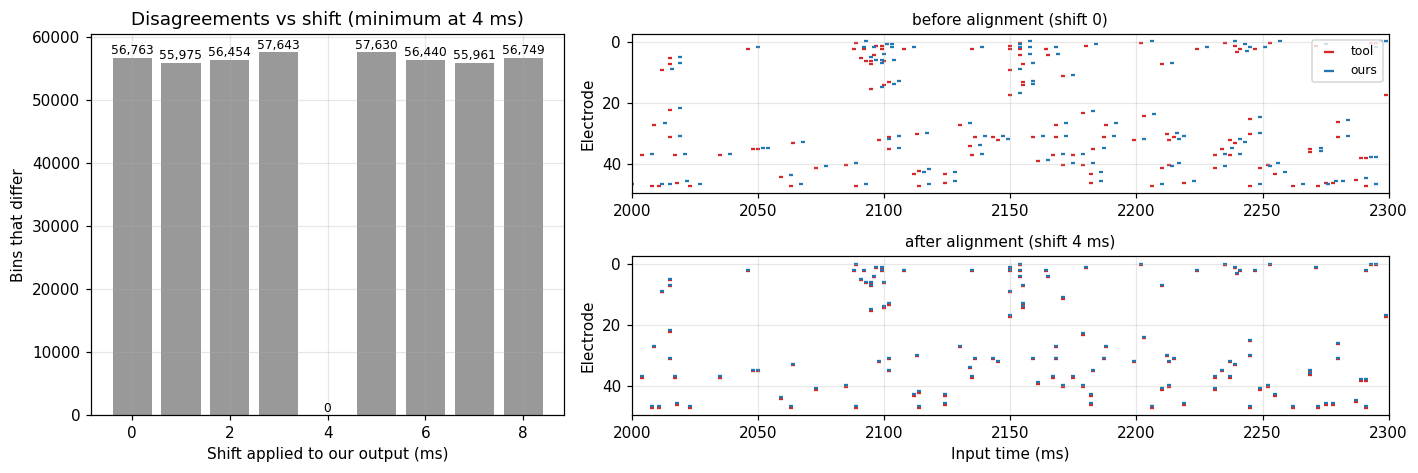

In [3]:
lags = np.arange(0, 9)
n_tool = tool["crossings"].shape[1]
per_lag = []
for lag in lags:
    n = min(n_tool, ours["spikes"].shape[1] - lag)
    per_lag.append(int((tool["crossings"][:, :n] != ours["spikes"][:, lag:lag + n]).sum()))
best_lag = int(lags[int(np.argmin(per_lag))])

fig = plt.figure(figsize=(13, 4.4))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.6])
ax = fig.add_subplot(gs[:, 0])
ax.bar(lags, per_lag, color=["0.6" if l != LAG_WINDOWS else C_OURS for l in lags])
ax.set_xlabel("Shift applied to our output (ms)"); ax.set_ylabel("Bins that differ"); ax.set_title(f"Disagreements vs shift (minimum at {best_lag} ms)")
for l, v in zip(lags, per_lag):
    ax.text(l, v + max(per_lag) * 0.01, f"{v:,}", ha="center", fontsize=8)

t0_ms, span, chans = 2000, 300, slice(0, 48)
for row, (title, shift) in enumerate((("before alignment (shift 0)", 0), (f"after alignment (shift {LAG_WINDOWS} ms)", LAG_WINDOWS))):
    ax = fig.add_subplot(gs[row, 1])
    tw = tool["timestamps"] // SAMPLES_PER_WINDOW
    tsel = (tw >= t0_ms) & (tw < t0_ms + span)
    c_t, w_t = np.nonzero(tool["crossings"][chans][:, tsel]); w_t = tw[tsel][w_t]
    c_o, w_o = np.nonzero(ours["spikes"][chans, t0_ms + shift:t0_ms + span + shift]); w_o = w_o + t0_ms
    ax.scatter(w_t, c_t + 0.25, s=9, marker="_", color=C_TOOL, label="tool")
    ax.scatter(w_o, c_o - 0.25, s=9, marker="_", color=C_OURS, label="ours")
    ax.set_xlim(t0_ms, t0_ms + span); ax.set_ylabel("Electrode"); ax.set_title(title, fontsize=10); ax.invert_yaxis()
    if row == 0:
        ax.legend(loc="upper right", fontsize=8, markerscale=2)
    else:
        ax.set_xlabel("Input time (ms)")
fig.tight_layout(); plt.show()


## Disagreements after alignment

Every output window of every electrode, tool against ours, shifted by the filter delay.

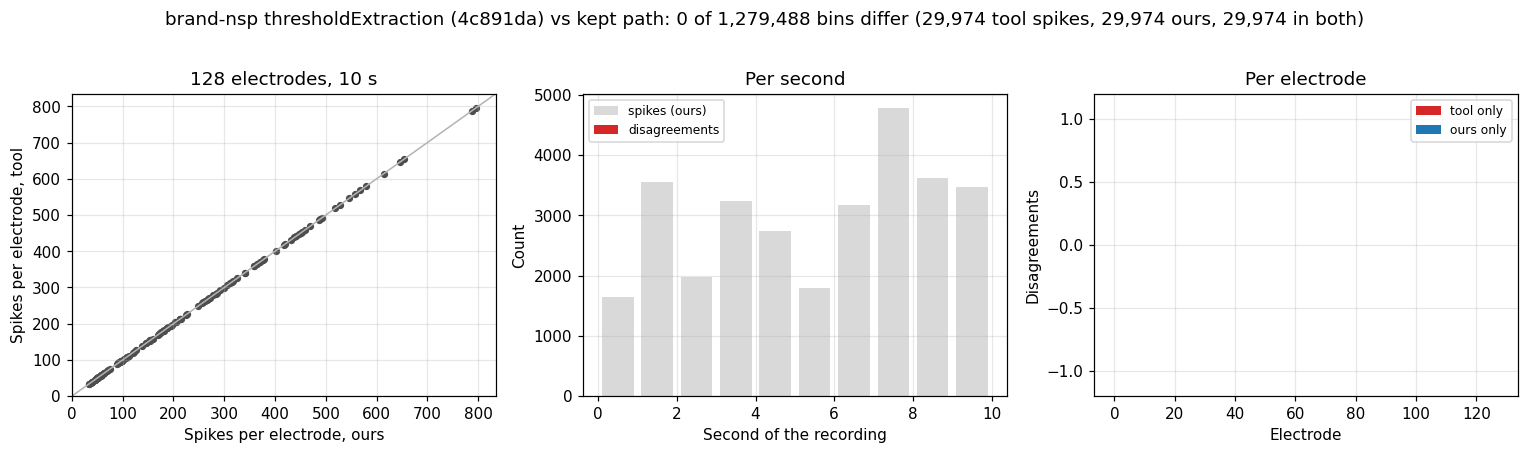

In [4]:
tool_al, ours_al, w_in = align(tool, ours["spikes"])
both = (tool_al == 1) & (ours_al == 1)
only_tool = (tool_al == 1) & (ours_al == 0)
only_ours = (tool_al == 0) & (ours_al == 1)
RESULT = dict(windows=int(tool_al.size), spikes_tool=int(tool_al.sum()), spikes_ours=int(ours_al.sum()),
              both=int(both.sum()), only_tool=int(only_tool.sum()), only_ours=int(only_ours.sum()))
RESULT["disagree"] = RESULT["only_tool"] + RESULT["only_ours"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ax = axes[0]
ct, co = tool_al.sum(1), ours_al.sum(1)
ax.scatter(co, ct, s=14, color="0.3"); lim = max(ct.max(), co.max()) * 1.05
ax.plot([0, lim], [0, lim], color="0.7", lw=1); ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Spikes per electrode, ours"); ax.set_ylabel("Spikes per electrode, tool"); ax.set_title(f"{n_channels} electrodes, {SECONDS} s")
ax = axes[1]
sec = w_in // 1000
per_sec_dis = np.bincount(sec, weights=(only_tool | only_ours).sum(0), minlength=SECONDS)
per_sec_spk = np.bincount(sec, weights=ours_al.sum(0), minlength=SECONDS)
ax.bar(np.arange(SECONDS) + 0.5, per_sec_spk, color="0.85", label="spikes (ours)")
ax.bar(np.arange(SECONDS) + 0.5, per_sec_dis, color=C_TOOL, label="disagreements")
ax.set_xlabel("Second of the recording"); ax.set_ylabel("Count"); ax.set_title("Per second"); ax.legend(fontsize=8)
ax = axes[2]
ax.bar(np.arange(n_channels), only_tool.sum(1), color=C_TOOL, label="tool only")
ax.bar(np.arange(n_channels), -only_ours.sum(1), color=C_OURS, label="ours only")
ax.set_xlabel("Electrode"); ax.set_ylabel("Disagreements"); ax.set_title("Per electrode"); ax.legend(fontsize=8)
ymax = max(1, only_tool.sum(1).max(), only_ours.sum(1).max()) * 1.2; ax.set_ylim(-ymax, ymax)
fig.suptitle(f"{TOOL_NAME} vs kept path: {RESULT['disagree']:,} of {RESULT['windows']:,} bins differ "
             f"({RESULT['spikes_tool']:,} tool spikes, {RESULT['spikes_ours']:,} ours, {RESULT['both']:,} in both)", y=1.02)
fig.tight_layout(); plt.show()


## The filtered waveform

The node can also write its filtered signal (as int16). Same electrode and 30 ms as in `rust_results.ipynb`, and the distribution of (tool − ours) over every sample. Differences inside ±1 are the node's integer rounding.

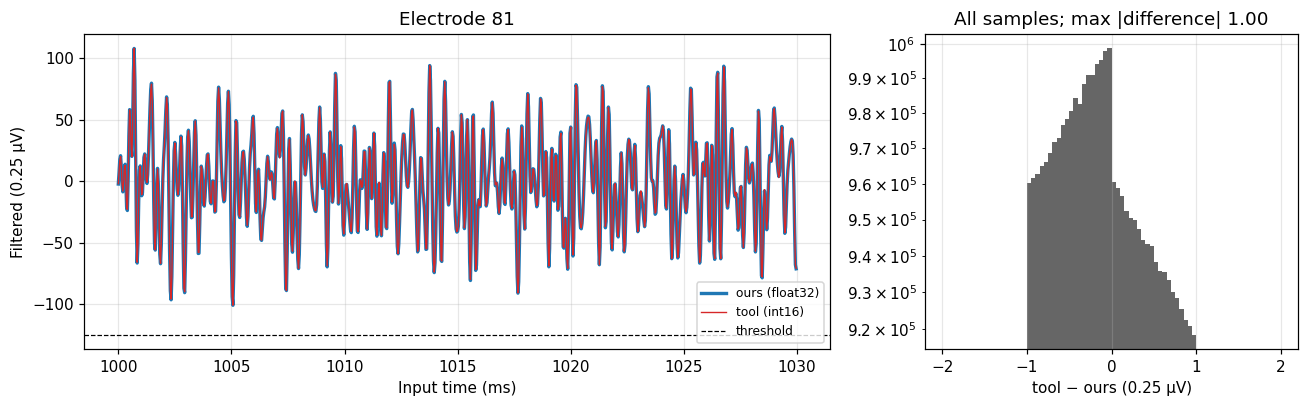

In [5]:
if tool["filtered"] is None:
    print("fallback in use: no tool waveform to compare")
else:
    lag = LAG_WINDOWS * SAMPLES_PER_WINDOW
    f_tool = tool["filtered"].astype(np.float32)
    n = f_tool.shape[1]
    f_ours = ours["filtered"][:, lag:lag + n]
    d = f_tool - f_ours
    ch, t0_ms, span = 81, 1000, 30
    s = slice(t0_ms * SAMPLES_PER_WINDOW, (t0_ms + span) * SAMPLES_PER_WINDOW)
    tt = np.arange(s.start, s.stop) / SAMPLES_PER_WINDOW
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [2, 1]})
    axes[0].plot(tt, f_ours[ch, s], color=C_OURS, lw=2.2, label="ours (float32)")
    axes[0].plot(tt, f_tool[ch, s], color=C_TOOL, lw=0.9, label="tool (int16)")
    axes[0].axhline(thresholds[ch], color="k", ls="--", lw=0.8, label="threshold")
    axes[0].set_xlabel("Input time (ms)"); axes[0].set_ylabel("Filtered (0.25 µV)"); axes[0].set_title(f"Electrode {ch}"); axes[0].legend(fontsize=8)
    axes[1].hist(d.ravel(), bins=np.linspace(-2, 2, 81), color="0.4"); axes[1].set_yscale("log")
    axes[1].set_xlabel("tool − ours (0.25 µV)"); axes[1].set_title(f"All samples; max |difference| {np.abs(d).max():.2f}")
    fig.tight_layout(); plt.show()
    WAVEFORM_MAX = float(np.abs(d).max())


## What the comparison caught

The first run of this comparison did **not** agree: 9,629 bins differed. The cause was in the project's parameter script, not in either pipeline. `calc_params.py` built the common-average weights with `reref_params[g, g] = 1/len(g)`, which in NumPy sets only the diagonal of the block, so the "CAR" file scaled each electrode by 63/64 and subtracted no common average at all. The node computes a real common average, so its filter saw different input. The line now fills the block (`np.ix_(g, g)`), the parameter file was regenerated, and the counts above are from the corrected file. The LRR branch of the script was always correct and every earlier timing used the LRR file.

The cell below reproduces the broken weights (diagonal only) with the regenerated thresholds, so the effect is visible next to the fixed one. The count is not exactly the first run's 9,629 because the thresholds in the regenerated file moved slightly too.

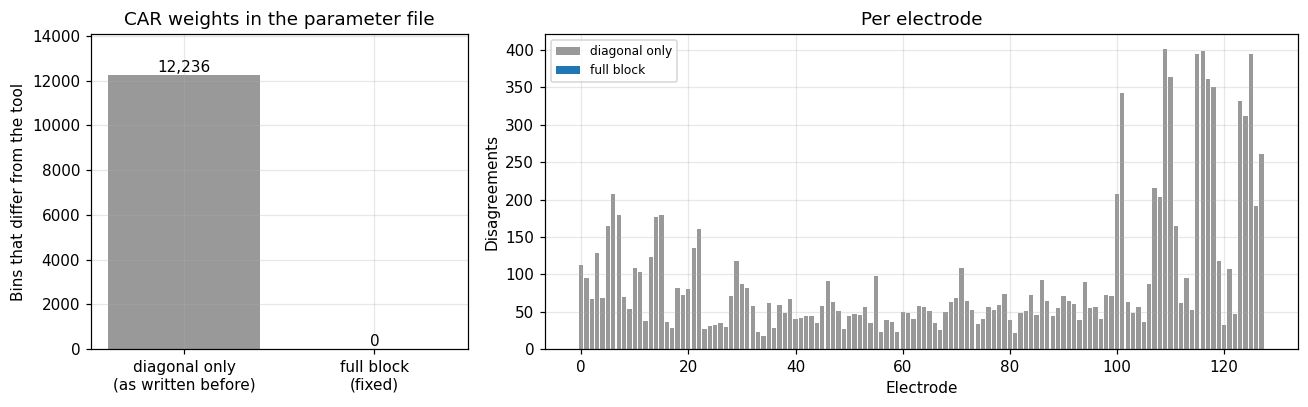

In [6]:
diag_only = np.diag(np.diag(reref))
broken = neurostream.Processor(diag_only, thresholds, groups).process_recording(raw)
b_tool, b_ours, b_w = align(tool, broken["spikes"])
b_dis = int((b_tool != b_ours).sum())
del broken

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 2]})
ax = axes[0]
ax.bar(["diagonal only\n(as written before)", "full block\n(fixed)"], [b_dis, RESULT["disagree"]], color=["0.6", C_OURS])
for i, v in enumerate((b_dis, RESULT["disagree"])):
    ax.text(i, v + 150, f"{v:,}", ha="center")
ax.set_ylim(0, b_dis * 1.15); ax.set_ylabel("Bins that differ from the tool"); ax.set_title("CAR weights in the parameter file")
ax = axes[1]
ax.bar(np.arange(n_channels), (b_tool != b_ours).sum(1), color="0.6", label="diagonal only")
ax.bar(np.arange(n_channels), (tool_al != ours_al).sum(1), color=C_OURS, label="full block")
ax.set_xlabel("Electrode"); ax.set_ylabel("Disagreements"); ax.set_title("Per electrode"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## A longer stretch

The same count over the first 60 s (spikes only; the node's waveform output is switched off to keep Redis small).

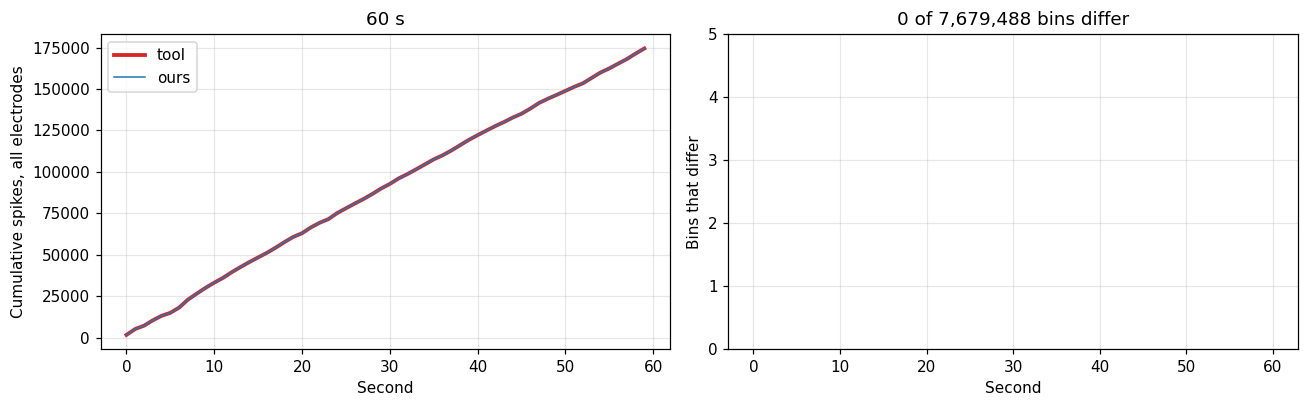

In [7]:
LONG_SECONDS = 60
raw60, _ = neurostream.read_ns6(DATA, max_samples=LONG_SECONDS * SAMPLE_RATE)
ours60 = neurostream.Processor(reref, thresholds, groups).process_recording(raw60)
spikes60 = ours60["spikes"]; del ours60
try:
    tool60 = run_node(raw60, thresholds, seconds=LONG_SECONDS, thresh_mult=P["thresh_mult"], output_filtered=False)
except Exception as exc:  # noqa: BLE001
    print("fallback in use for the long stretch:", exc)
    tool60 = whole_file_fallback(raw60, reref, thresholds, groups)
del raw60
t60, o60, w60 = align(tool60, spikes60)
LONG = dict(windows=int(t60.size), spikes_tool=int(t60.sum()), spikes_ours=int(o60.sum()), disagree=int((t60 != o60).sum()))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sec = w60 // 1000
axes[0].plot(np.cumsum(np.bincount(sec, weights=t60.sum(0))), color=C_TOOL, lw=2.5, label="tool")
axes[0].plot(np.cumsum(np.bincount(sec, weights=o60.sum(0))), color=C_OURS, lw=1, label="ours")
axes[0].set_xlabel("Second"); axes[0].set_ylabel("Cumulative spikes, all electrodes"); axes[0].legend(); axes[0].set_title(f"{LONG_SECONDS} s")
axes[1].bar(np.arange(LONG_SECONDS) + 0.5, np.bincount(sec, weights=(t60 != o60).sum(0), minlength=LONG_SECONDS), color=C_TOOL)
axes[1].set_xlabel("Second"); axes[1].set_ylabel("Bins that differ"); axes[1].set_title(f"{LONG['disagree']:,} of {LONG['windows']:,} bins differ")
axes[1].set_ylim(0, max(5, axes[1].get_ylim()[1]))
fig.tight_layout(); plt.show()


## Throughput, for context only

The node's time is the span from its first to its last output while all the data was already waiting in Redis, so it includes reading and writing Redis entries every millisecond, which is how the node is meant to run; it is a separate process with Python-level work per millisecond. The other two bars are the kept path on the same 10 s. This graph is not what the week is about; the disagreement count is.

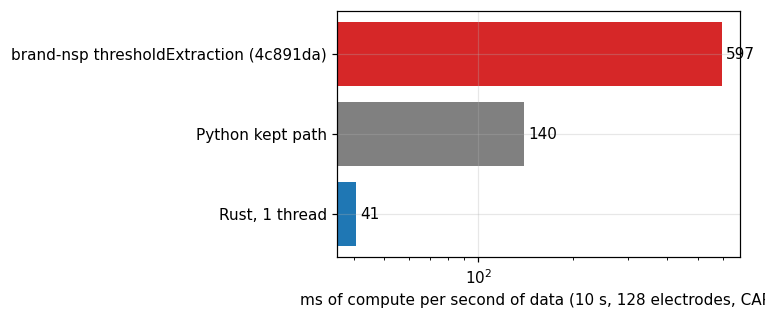

In [8]:
times = {TOOL_NAME: tool["node_span_seconds"] / SECONDS * 1000, "Python kept path": t_py / SECONDS * 1000, "Rust, 1 thread": t_rust / SECONDS * 1000}
fig, ax = plt.subplots(figsize=(7, 3))
names = list(times)
ax.barh(names, [times[n] for n in names], color=[C_TOOL, "0.5", C_OURS])
for i, n in enumerate(names):
    ax.text(times[n] * 1.03, i, f"{times[n]:.0f}" if np.isfinite(times[n]) else "n/a", va="center")
ax.set_xscale("log"); ax.invert_yaxis(); ax.set_xlabel(f"ms of compute per second of data ({SECONDS} s, {n_channels} electrodes, CAR)")
fig.tight_layout(); plt.show()


## Summary

In [9]:
print(f"Tool: {TOOL_NAME}, run on this machine through Redis, unmodified.")
print(f"Stretch: first {SECONDS} s of NSP1_aligned.ns6, {n_channels} electrodes, shared CAR thresholds.")
print(f"Alignment: minimum disagreement at a shift of {best_lag} ms (expected {LAG_WINDOWS} ms, the filter delay).")
print(f"After alignment: {RESULT['disagree']:,} of {RESULT['windows']:,} bins differ "
      f"({RESULT['spikes_tool']:,} tool spikes, {RESULT['spikes_ours']:,} ours; tool only {RESULT['only_tool']}, ours only {RESULT['only_ours']}).")
if tool["filtered"] is not None:
    print(f"Waveform: max |tool − ours| = {WAVEFORM_MAX:.2f} (the tool writes int16).")
print(f"First {LONG_SECONDS} s: {LONG['disagree']:,} of {LONG['windows']:,} bins differ ({LONG['spikes_tool']:,} vs {LONG['spikes_ours']:,} spikes).")
print(f"With the diagonal-only CAR weights the parameter script wrote before the fix: {b_dis:,} bins differ.")


Tool: brand-nsp thresholdExtraction (4c891da), run on this machine through Redis, unmodified.
Stretch: first 10 s of NSP1_aligned.ns6, 128 electrodes, shared CAR thresholds.
Alignment: minimum disagreement at a shift of 4 ms (expected 4 ms, the filter delay).
After alignment: 0 of 1,279,488 bins differ (29,974 tool spikes, 29,974 ours; tool only 0, ours only 0).
Waveform: max |tool − ours| = 1.00 (the tool writes int16).
First 60 s: 0 of 7,679,488 bins differ (174,453 vs 174,453 spikes).
With the diagonal-only CAR weights the parameter script wrote before the fix: 12,236 bins differ.
